In [1]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../scaled_emotion_dataset.parquet")

emotion_columns = [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise",
    "neutral"
]

X_scaled = df[emotion_columns]

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

dbscan = DBSCAN(
    eps=2.6,
    min_samples=10,
    metric="euclidean"
)

labels = dbscan.fit_predict(X_scaled)

mask = labels != -1

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise:", (labels == -1).sum())

if len(set(labels[mask])) > 1:
    print("Silhouette:", silhouette_score(X_scaled[mask], labels[mask]))
    print("Davies-Bouldin:", davies_bouldin_score(X_scaled[mask], labels[mask]))

Clusters: 4
Noise: 1179
Silhouette: 0.2744788395725051
Davies-Bouldin: 0.6330733862381501


c:\Users\pramo\OneDrive\Desktop\Social Media and Mental Health\mental-health-using-emotions\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\pramo\OneDrive\Desktop\Social Media and Mental Health\mental-health-using-emotions\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


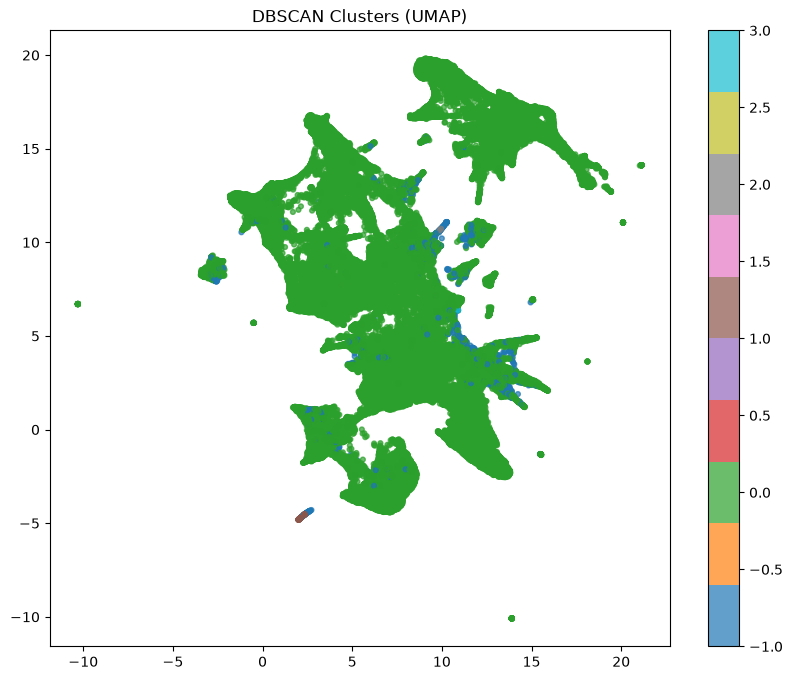

In [4]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=labels,
    cmap="tab10",
    s=12,
    alpha=0.7
)

plt.colorbar(scatter)
plt.title("DBSCAN Clusters (UMAP)")
plt.show()